<a href="https://colab.research.google.com/github/Priyankapanda89/Decodelabs/blob/main/Project2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Import Libraries

In [23]:
import pandas as pd
import numpy as np

Load Dataset

In [24]:
df = pd.read_excel("/content/Dataset for Data Analytics (1).xlsx")

In [26]:
df.head()

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04


Dataset Overview

In [27]:
print("Number of Rows:",df.shape[0])
print("Number of Columns:",df.shape[1])

print("\nColumn Names:")
print(df.columns)

print("\nDatatypes:")
print(df.dtypes)

Number of Rows: 1200
Number of Columns: 14

Column Names:
Index(['OrderID', 'Date', 'CustomerID', 'Product', 'Quantity', 'UnitPrice',
       'ShippingAddress', 'PaymentMethod', 'OrderStatus', 'TrackingNumber',
       'ItemsInCart', 'CouponCode', 'ReferralSource', 'TotalPrice'],
      dtype='object')

Datatypes:
OrderID                    object
Date               datetime64[ns]
CustomerID                 object
Product                    object
Quantity                    int64
UnitPrice                 float64
ShippingAddress            object
PaymentMethod              object
OrderStatus                object
TrackingNumber             object
ItemsInCart                 int64
CouponCode                 object
ReferralSource             object
TotalPrice                float64
dtype: object


In [30]:
print("Mean Quantity:",df["Quantity"].mean())
print("Median Quantity:",df["Quantity"].median())
print("Mode Quantity:",df["Quantity"].mode())
print("Count:",df["Quantity"].count())

Mean Quantity: 2.9458333333333333
Median Quantity: 3.0
Mode Quantity: 0    1
Name: Quantity, dtype: int64
Count: 1200


Unit price statistics

In [31]:
print("Mean Unit Price:", df["UnitPrice"].mean())
print("Median Unit Price:", df["UnitPrice"].median())
print("Mode Unit Price:", df["UnitPrice"].mode())
print("Count:", df["UnitPrice"].count())

Mean Unit Price: 356.41275
Median Unit Price: 364.21
Mode Unit Price: 0    127.18
1    133.39
2    136.84
3    183.67
4    228.91
5    466.42
6    629.34
Name: UnitPrice, dtype: float64
Count: 1200


Total Price Statistics

In [33]:
print("Mean Total Price:", df["TotalPrice"].mean())
print("Median Total Price:", df["TotalPrice"].median())
print("Mode Total Price:", df["TotalPrice"].mode())
print("Count:", df["TotalPrice"].count())

Mean Total Price: 1053.9683
Median Total Price: 823.615
Mode Total Price: 0     211.14
1     367.34
2     410.52
3     635.90
4    2517.36
Name: TotalPrice, dtype: float64
Count: 1200


Order Status Analysis

In [34]:
print(df['OrderStatus'].value_counts())

OrderStatus
Cancelled    250
Returned     247
Pending      237
Shipped      235
Delivered    231
Name: count, dtype: int64


Product Analysis

In [35]:
product_sales = df.groupby("Product")["TotalPrice"].sum()
print(product_sales.sort_values(ascending=False))

Product
Chair      195620.11
Printer    195612.61
Laptop     192126.56
Tablet     186568.95
Monitor    175651.41
Desk       167459.93
Phone      151722.39
Name: TotalPrice, dtype: float64


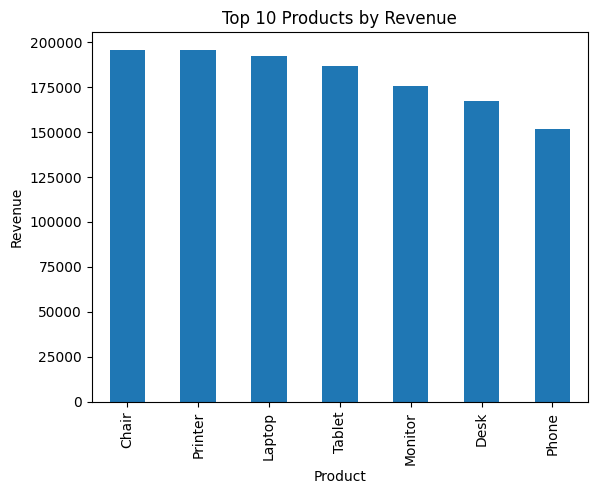

In [36]:
import matplotlib.pyplot as plt
product_sales.sort_values(ascending =False).head(10).plot(
    kind = "bar"
)
plt.title("Top 10 Products by Revenue")
plt.ylabel("Revenue")
plt.show()

Referral Source Analysis

In [38]:
referral = df["ReferralSource"].value_counts()
print(referral)

ReferralSource
Instagram    259
Email        250
Google       241
Facebook     228
Referral     222
Name: count, dtype: int64


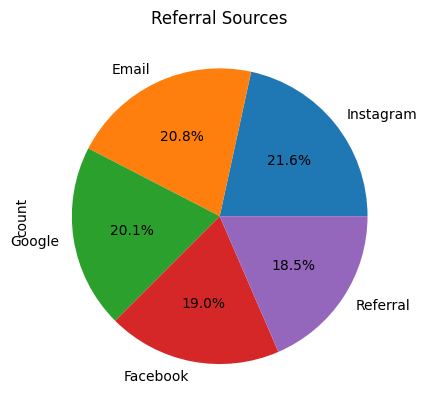

In [39]:
referral.plot(kind = "pie", autopct ="%1.1f%%")
plt.title("Referral Sources")
plt.show()

Payment Method Analysis

In [40]:
payment = df["PaymentMethod"].value_counts()
print(payment)


PaymentMethod
Online         258
Cash           246
Credit Card    234
Debit Card     232
Gift Card      230
Name: count, dtype: int64


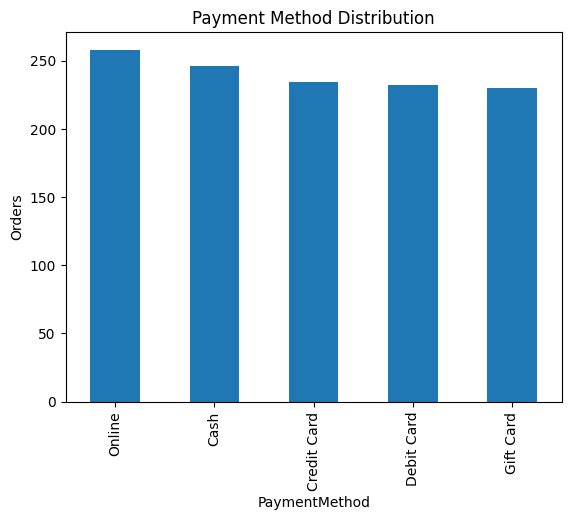

In [41]:
payment.plot(kind = "bar")
plt.title("Payment Method Distribution")
plt.ylabel("Orders")
plt.show()

Trend Analysis(Year wise Revenue)

In [44]:
df["Date"] = pd.to_datetime(df['Date'])
yearly_sales = df.groupby(df["Date"].dt.year)["TotalPrice"].sum()
print(yearly_sales)

Date
2023    552643.24
2024    480235.87
2025    231882.85
Name: TotalPrice, dtype: float64


Line Chart

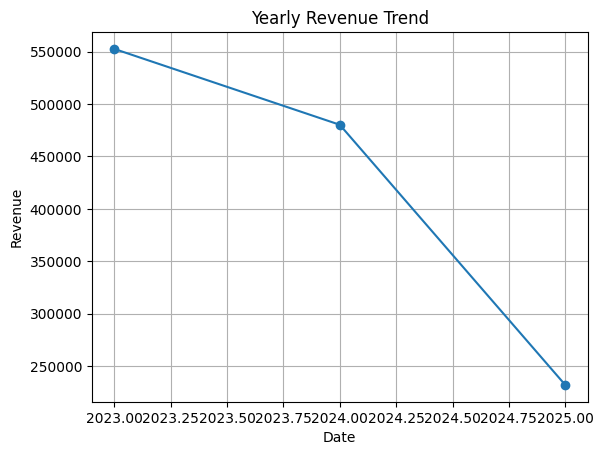

In [45]:
yearly_sales.plot(marker = "o")
plt.title("Yearly Revenue Trend")
plt.ylabel("Revenue")
plt.grid(True)
plt.show()

Outlier Detection

In [46]:
Q1 = df["TotalPrice"].quantile(0.25)
Q3 = df["TotalPrice"].quantile(0.75)

IQR = Q3 - Q1
lower = Q1-1.5*IQR
upper = Q3+1.5*IQR

outliers = df[
    (df["TotalPrice"]<lower)|
    (df["TotalPrice"]>upper)
]
print("Number of Outliers:", len(outliers))

Number of Outliers: 8


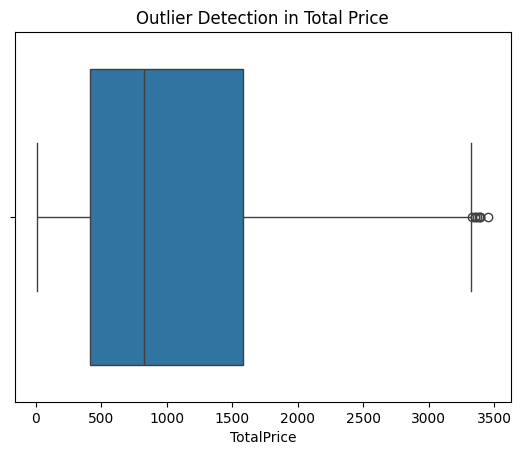

In [47]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x = df["TotalPrice"])

plt.title("Outlier Detection in Total Price")
plt.show()

correlation analysis

In [48]:
corr = df[["Quantity", "UnitPrice", "ItemsInCart","TotalPrice"]].corr()
print(corr)

             Quantity  UnitPrice  ItemsInCart  TotalPrice
Quantity     1.000000   0.014553     0.650061    0.615251
UnitPrice    0.014553   1.000000     0.000602    0.717081
ItemsInCart  0.650061   0.000602     1.000000    0.392540
TotalPrice   0.615251   0.717081     0.392540    1.000000


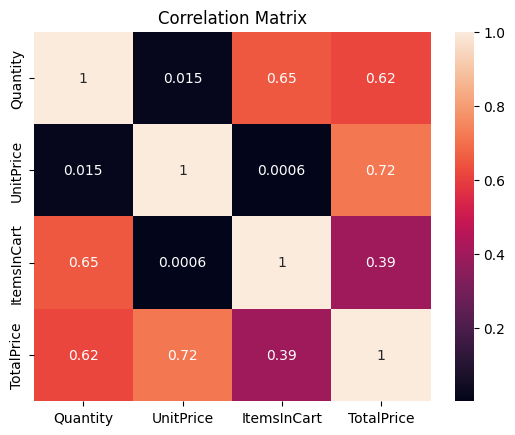

In [49]:
sns.heatmap(corr, annot =True)

plt.title("Correlation Matrix")
plt.show()